# Notebook 13 — 3D constraint coverage: per-voxel framing of the 6-tet check

Companion to [12_3d-tetrahedral-check.ipynb](12_3d-tetrahedral-check.ipynb).

The 2D 2-triangle check (`triangle_sign_det2D`) has a beautiful structural property — for every interior pixel `(px, py)`, **two** triangles are anchored at it (`T1` from the cell to its `-x` side, `T2` from its own cell). Iterating across all pixels gives full coverage of the 2D grid with **no duplicate triangles** — every triangle of the cell tiling is owned by exactly one anchor pixel.

This notebook lifts that framing to 3D and verifies the same property holds for our **6-tet body-diagonal decomposition**:

- per anchor voxel `(z, y, x)`, **six** tets are anchored at it (drawn from up to 3 different cells: the cell to the `-x`, `-y`, and `-z` sides);
- iterating across all voxels covers the entire 3D volume;
- no two tets share interior — the constraint set in [notebook 12](12_3d-tetrahedral-check.ipynb) has zero duplication, just relabeled to match the per-voxel structure.

We confirm this **numerically** (sum of signed tet volumes = grid volume, all 48 vertex sets distinct on a 3³ grid) and **visually** (matplotlib + interactive plotly, every tet colour-grouped by its anchor voxel).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict
import plotly.graph_objects as go

# Helper printer for short coverage reports.
def report(label, ok, extra=''):
    mark = 'OK' if ok else 'FAIL'
    print(f'  [{mark}]  {label}' + (f'  --  {extra}' if extra else ''))

## Step 1 — 2D refresher: per-pixel 2-triangle structure

For every interior pixel `(px, py)` (where `0 \u2264 py \u2264 H-2`), the 2D 2-triangle check assigns:

- **T1** at `(px, py)`: vertices `(px, py)`, `(px-1, py+1)`, `(px, py+1)` — exists for `px \u2265 1`. Geometrically this is the lower-right triangle of the cell `(cy=py, cx=px-1)`.
- **T2** at `(px, py)`: vertices `(px, py)`, `(px, py+1)`, `(px+1, py)` — exists for `px \u2264 W-2`. The upper-left triangle of the cell `(cy=py, cx=px)`.

Iterating across all anchor pixels:

- Each cell's lower-right triangle is owned by **exactly** one anchor pixel (its `(cx+1, cy)` corner).
- Each cell's upper-left triangle is owned by **exactly** one anchor pixel (its `(cx, cy)` corner).
- Total triangles = `2 \u00b7 (H-1) \u00b7 (W-1)` — matches the per-cell count.
- Sum of triangle areas = `(H-1) \u00b7 (W-1)` = full grid area.

Below, every triangle on a 5×5 grid is drawn coloured by its anchor pixel (one colour per anchor). Iterating gives the complete tiling.

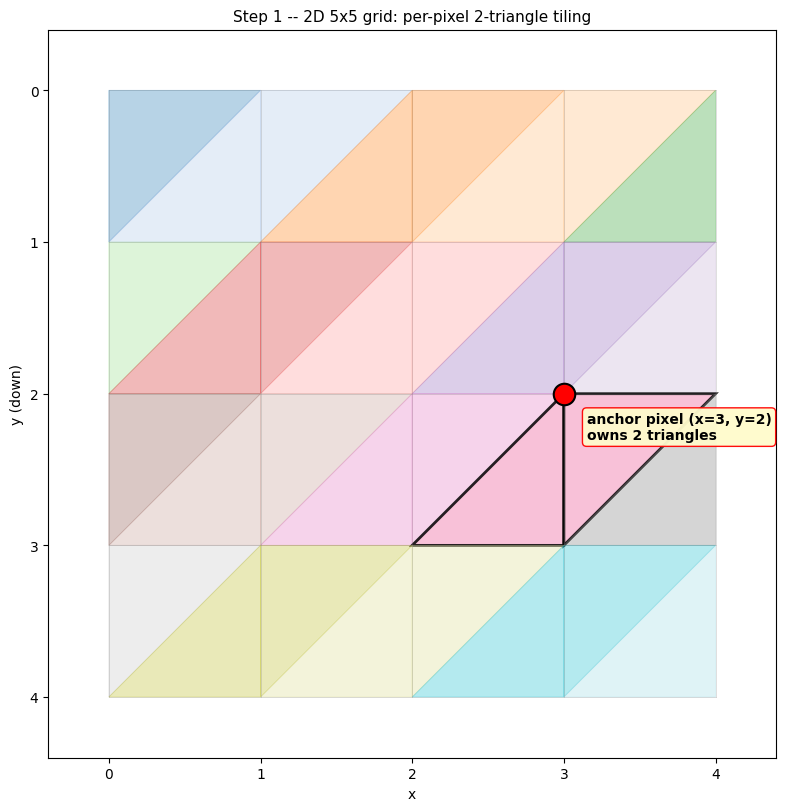


2D coverage report (5x5 grid):
  total triangles            : 32
  expected = 2*(H-1)*(W-1)   : 32
  sum of triangle areas      : 16.0000
  expected = (H-1)*(W-1)     : 16
  unique triangle vertex sets: 32  (matches total -> no duplicates)

  [OK]  total triangle count
  [OK]  full coverage (sum of areas)
  [OK]  no duplicate triangles


In [2]:
H_2D, W_2D = 5, 5

# Iterate anchor pixels and collect (anchor, T1/T2 triangles).
ANCHOR_COLORS_2D = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)
triangles_by_anchor = []
n_total = 0
total_area = 0.0
all_tri_keys = set()  # for duplicate detection

for py in range(H_2D - 1):
    for px in range(W_2D):
        tris = []
        if px > 0:
            v = ((px, py), (px - 1, py + 1), (px, py + 1))
            tris.append(('T1', v))
        if px < W_2D - 1:
            v = ((px, py), (px, py + 1), (px + 1, py))
            tris.append(('T2', v))
        if tris:
            triangles_by_anchor.append((px, py, tris))

# Plot.
fig, ax = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')

showcase = (3, 2)
for k, (px, py, tris) in enumerate(triangles_by_anchor):
    color = ANCHOR_COLORS_2D[k % len(ANCHOR_COLORS_2D)]
    is_show = (px, py) == showcase
    alpha = 0.85 if is_show else 0.32
    edge = '#000000' if is_show else color
    lw = 2.0 if is_show else 0.6
    for label, verts in tris:
        poly = MplPolygon(verts, closed=True, facecolor=color, alpha=alpha,
                          edgecolor=edge, linewidth=lw)
        ax.add_patch(poly)
        n_total += 1
        # Signed area.
        x = [v[0] for v in verts]; y = [v[1] for v in verts]
        a = 0.5 * abs(x[0]*(y[1]-y[2]) + x[1]*(y[2]-y[0]) + x[2]*(y[0]-y[1]))
        total_area += a
        # Duplicate detection key (sorted vertex tuple).
        key = tuple(sorted(verts))
        if key in all_tri_keys:
            print(f'DUPLICATE: triangle {verts} appears twice')
        all_tri_keys.add(key)

# Showcase pixel marker + annotation.
sx, sy = showcase
ax.scatter(sx, sy, color='red', s=240, edgecolor='black', linewidth=1.5, zorder=20)
ax.text(sx + 0.15, sy + 0.30, 'anchor pixel (x=' + str(sx) + ', y=' + str(sy) + ')\nowns 2 triangles',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.30', facecolor='#fffbcc',
                  edgecolor='red', linewidth=1.0, alpha=0.95))

# Reference grid.
for x in range(W_2D):
    ax.plot([x, x], [0, H_2D - 1], color='gray', lw=0.4, alpha=0.45)
for y in range(H_2D):
    ax.plot([0, W_2D - 1], [y, y], color='gray', lw=0.4, alpha=0.45)

ax.set_xlabel('x'); ax.set_ylabel('y (down)')
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlim(-0.4, W_2D - 0.6)
ax.set_ylim(H_2D - 0.6, -0.4)
ax.set_title('Step 1 -- 2D 5x5 grid: per-pixel 2-triangle tiling',
             fontsize=11)
plt.show()

# Coverage diagnostics.
print()
print('2D coverage report (5x5 grid):')
print('  total triangles            : ' + str(n_total))
print('  expected = 2*(H-1)*(W-1)   : ' + str(2 * (H_2D-1) * (W_2D-1)))
print('  sum of triangle areas      : ' + format(total_area, '.4f'))
print('  expected = (H-1)*(W-1)     : ' + str((H_2D-1) * (W_2D-1)))
print('  unique triangle vertex sets: ' + str(len(all_tri_keys)) + '  (matches total -> no duplicates)')
print()
report('total triangle count',
       n_total == 2 * (H_2D-1) * (W_2D-1))
report('full coverage (sum of areas)',
       abs(total_area - (H_2D-1) * (W_2D-1)) < 1e-9)
report('no duplicate triangles',
       len(all_tri_keys) == n_total)

## Step 2 — 3D analog: per-voxel 6-tet structure

Lifting the same idea to 3D: in our 6-tet body-diagonal decomposition, every tet of cell `(cz, cy, cx)` is anchored at one of its 4 vertices. We pick the **second vertex** of the `(v0, A, B, v7)` ordering (the path's `v_A`) — that is the cube corner the path *first* steps to from `v0`. This gives a clean per-axis grouping:

| tets | path begins along | local anchor `v_A` | offset from cell origin | global anchor voxel |
|---|---|---|---|---|
| `T0, T1` | x-axis | `v1` | `(z=0, y=0, x=1)` | `(cz, cy, cx+1)` |
| `T2, T3` | y-axis | `v2` | `(z=0, y=1, x=0)` | `(cz, cy+1, cx)` |
| `T4, T5` | z-axis | `v4` | `(z=1, y=0, x=0)` | `(cz+1, cy, cx)` |

**Iterating across anchor voxels** then gives, per voxel `(z, y, x)`:

- 2 tets `(T0, T1)` from cell `(z, y, x-1)` — the cell to the `-x` side
- 2 tets `(T2, T3)` from cell `(z, y-1, x)` — the cell to the `-y` side
- 2 tets `(T4, T5)` from cell `(z-1, y, x)` — the cell to the `-z` side

**Up to 6 tets per voxel** (fewer at boundaries, where one or more contributing cells fall outside the grid). This is the structural 3D analog of the 2D rule: in 2D, an anchor pixel owns triangles drawn from the 2 cells on its `±x` sides; in 3D, an anchor voxel owns tets drawn from the 3 cells on its `-x`, `-y`, `-z` sides.

The visualisation below renders the 3×3×3 grid (= 2³ = 8 cells, 48 tets) with every tet colour-grouped by its anchor voxel.

In [3]:
CUBE_CORNERS = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],
                          [1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype=int)
TET_INDICES  = np.array([[0,1,3,7],[0,1,5,7],[0,2,3,7],
                          [0,2,6,7],[0,4,5,7],[0,4,6,7]], dtype=int)
ANCHOR_OFFSETS = np.array([[0,0,1],[0,0,1],[0,1,0],
                            [0,1,0],[1,0,0],[1,0,0]], dtype=int)
TET_PATHS = ['x,y,z', 'x,z,y', 'y,x,z', 'y,z,x', 'z,x,y', 'z,y,x']
# Calibrated sign flip (same as notebook 12): even path orderings -> +1, odd -> -1.
TET_SIGN_FLIP = np.array([+1, -1, -1, +1, +1, -1])

CUBE_EDGES = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),
              (4,5),(4,6),(5,7),(6,7)]


def cell_tet_xyz(cz, cy, cx, t):
    """Return the (4, 3) array of (x, y, z) voxel positions of tet t in cell (cz, cy, cx)."""
    inds = TET_INDICES[t]
    return np.array([[cx + CUBE_CORNERS[i][2],
                      cy + CUBE_CORNERS[i][1],
                      cz + CUBE_CORNERS[i][0]] for i in inds], dtype=float)


def signed_volume_xyz(pts):
    a, b, c, d = pts
    return float(np.dot(b - a, np.cross(c - a, d - a))) / 6.0


def build_tets(D, H, W):
    """Build every (cell, tet, anchor, vertices) entry for a D x H x W voxel grid."""
    out = []
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for t in range(6):
                    az, ay, ax_a = ANCHOR_OFFSETS[t]
                    out.append({
                        'cell':   (cz, cy, cx),
                        'tet':    int(t),
                        'anchor': (cz + az, cy + ay, cx + ax_a),
                        'xyz':    cell_tet_xyz(cz, cy, cx, t),
                    })
    return out

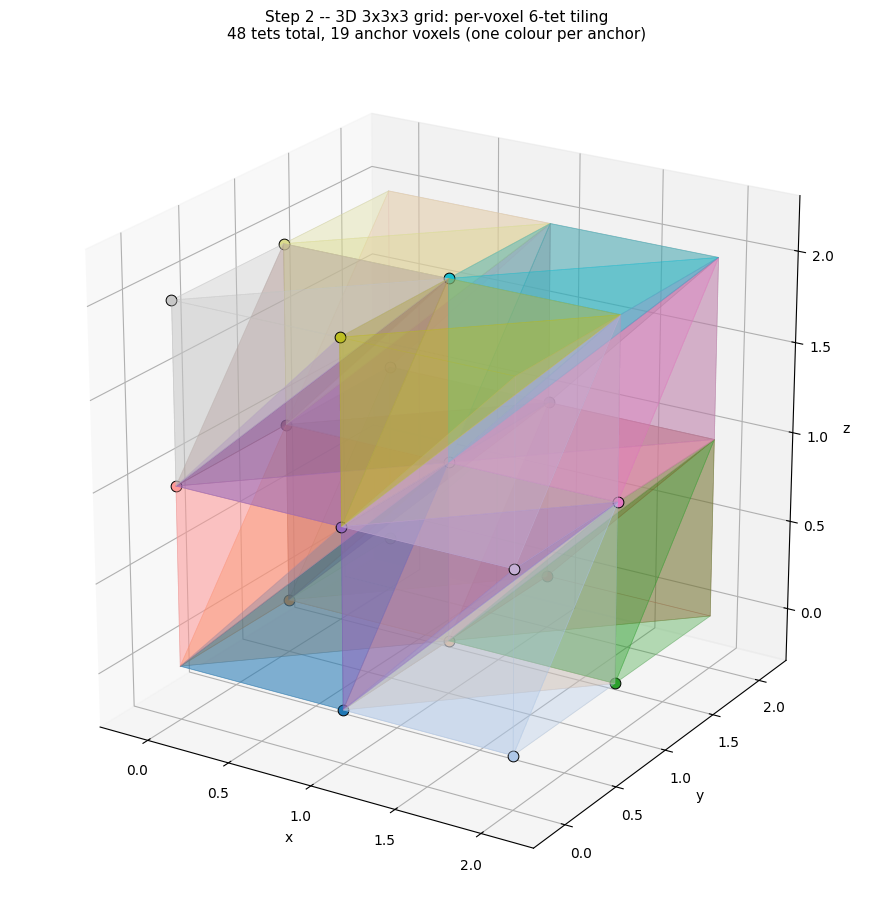


Anchor distribution (3x3x3 grid):
  15 anchor voxels each own 2 tet(s)
  3 anchor voxels each own 4 tet(s)
  1 anchor voxels each own 6 tet(s)

  total owned tets : 48
  total tets built : 48


In [4]:
D, H, W = 3, 3, 3
all_tets = build_tets(D, H, W)
by_anchor = defaultdict(list)
for tt in all_tets:
    by_anchor[tt['anchor']].append(tt)

# Static matplotlib: every tet coloured by its anchor voxel.
ANCHOR_COLORS_3D = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)

fig = plt.figure(figsize=(11, 9), layout='constrained')
ax = fig.add_subplot(111, projection='3d')

# Faint cell skeleton.
for cz in range(D - 1):
    for cy in range(H - 1):
        for cx in range(W - 1):
            for i, j in CUBE_EDGES:
                pi = CUBE_CORNERS[i]; pj = CUBE_CORNERS[j]
                ax.plot([cx + pi[2], cx + pj[2]],
                        [cy + pi[1], cy + pj[1]],
                        [cz + pi[0], cz + pj[0]],
                        color='#cfcfcf', lw=0.5, alpha=0.6)

# Tets coloured by anchor.
sorted_anchors = sorted(by_anchor.items())
for k, (anchor, tets) in enumerate(sorted_anchors):
    color = ANCHOR_COLORS_3D[k % len(ANCHOR_COLORS_3D)]
    for tt in tets:
        pts = tt['xyz']
        faces = [
            [pts[0], pts[1], pts[2]],
            [pts[0], pts[1], pts[3]],
            [pts[0], pts[2], pts[3]],
            [pts[1], pts[2], pts[3]],
        ]
        ax.add_collection3d(Poly3DCollection(
            faces, facecolor=color, alpha=0.18,
            edgecolor=color, linewidth=0.5))
    # Anchor voxel marker.
    az, ay, ax_v = anchor
    ax.scatter([ax_v], [ay], [az], color=color, s=60,
               edgecolor='black', linewidth=0.7, zorder=10)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_xlim(-0.3, W - 0.7); ax.set_ylim(-0.3, H - 0.7); ax.set_zlim(-0.3, D - 0.7)
ax.set_box_aspect((W, H, D))
ax.view_init(elev=22, azim=-58)
ax.set_title('Step 2 -- 3D ' + str(D) + 'x' + str(H) + 'x' + str(W) +
             ' grid: per-voxel 6-tet tiling\n' +
             str(len(all_tets)) + ' tets total, ' + str(len(by_anchor)) +
             ' anchor voxels (one colour per anchor)',
             fontsize=11)
plt.show()

# Anchor-distribution table.
counts = defaultdict(int)
for a, ts in by_anchor.items():
    counts[len(ts)] += 1
print()
print('Anchor distribution (3x3x3 grid):')
total_owned = 0
for k in sorted(counts):
    print('  ' + str(counts[k]) + ' anchor voxels each own ' + str(k) + ' tet(s)')
    total_owned += counts[k] * k
print()
print('  total owned tets : ' + str(total_owned))
print('  total tets built : ' + str(len(all_tets)))

In [5]:
# Interactive plotly view: every tet drawn as edge segments coloured by anchor;
# legend lets you toggle individual anchor groups on/off to see overlap-free tiling.
fig = go.Figure()

TET_EDGES = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
PLOTLY_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b',
                 '#e377c2','#7f7f7f','#bcbd22','#17becf','#aec7e8','#ffbb78',
                 '#98df8a','#ff9896','#c5b0d5','#c49c94','#f7b6d2','#c7c7c7',
                 '#dbdb8d','#9edae5','#393b79','#637939','#8c6d31','#843c39']

for k, (anchor, tets) in enumerate(sorted(by_anchor.items())):
    color = PLOTLY_COLORS[k % len(PLOTLY_COLORS)]
    xs, ys, zs = [], [], []
    for tt in tets:
        pts = tt['xyz']
        for i, j in TET_EDGES:
            xs.extend([pts[i, 0], pts[j, 0], np.nan])
            ys.extend([pts[i, 1], pts[j, 1], np.nan])
            zs.extend([pts[i, 2], pts[j, 2], np.nan])
    az, ay, ax_v = anchor
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs, mode='lines',
        line=dict(color=color, width=3),
        name='anchor (' + str(az) + ',' + str(ay) + ',' + str(ax_v) +
             '): ' + str(len(tets)) + ' tet(s)',
        legendgroup='a' + str(k),
    ))
    fig.add_trace(go.Scatter3d(
        x=[ax_v], y=[ay], z=[az], mode='markers',
        marker=dict(size=6, color=color, line=dict(color='black', width=1)),
        showlegend=False, legendgroup='a' + str(k),
    ))

fig.update_layout(
    title='Per-voxel 6-tet structure on a ' + str(D) + 'x' + str(H) + 'x' + str(W) +
          ' grid (interactive)<br>'
          '<sup>Click legend entries to toggle individual anchor groups -- '
          'verify visually that no two anchors\u2019 tets overlap.</sup>',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z', aspectmode='cube'),
    height=720, margin=dict(l=0, r=0, b=0, t=70),
    legend=dict(font=dict(size=9)),
)
fig.show()

In [6]:
# Numerical coverage and uniqueness checks.

# 1. Sum of signed volumes (with sign flip applied) == total cell volume.
total_vol = 0.0
for tt in all_tets:
    raw = signed_volume_xyz(tt['xyz'])
    total_vol += TET_SIGN_FLIP[tt['tet']] * raw
expected = (D - 1) * (H - 1) * (W - 1)

# 2. Every tet has a distinct vertex set (no duplicates).
vertex_sets = [frozenset(map(tuple, tt['xyz'].astype(int))) for tt in all_tets]
n_unique = len(set(vertex_sets))

# 3. Every cell's 6 tets sum to that cell's volume (=1) exactly.
per_cell_vol = defaultdict(float)
for tt in all_tets:
    raw = signed_volume_xyz(tt['xyz'])
    per_cell_vol[tt['cell']] += TET_SIGN_FLIP[tt['tet']] * raw
all_cell_vols_one = all(abs(v - 1.0) < 1e-9 for v in per_cell_vol.values())

# 4. Constraint count matches the per-cell formulation.
cells = (D - 1) * (H - 1) * (W - 1)
expected_constraints = 6 * cells

print('3D coverage report (' + str(D) + 'x' + str(H) + 'x' + str(W) + ' grid)')
print('=' * 60)
print('  cells                       : ' + str(cells))
print('  total tets                  : ' + str(len(all_tets)))
print('  expected = 6 * cells        : ' + str(expected_constraints))
print('  sum of signed volumes       : ' + format(total_vol, '.4f'))
print('  expected = (D-1)(H-1)(W-1)  : ' + str(expected))
print('  unique tet vertex sets      : ' + str(n_unique) + ' / ' + str(len(all_tets)))
print('  every cell sums to 1.0      : ' + str(all_cell_vols_one))
print()
report('total tet count matches per-cell formulation',
       len(all_tets) == expected_constraints)
report('full coverage (sum of volumes = #cells)',
       abs(total_vol - expected) < 1e-9)
report('every tet has a unique vertex set (no duplicates)',
       n_unique == len(all_tets))
report('every cell\u2019s 6 tets sum to that cell\u2019s volume',
       all_cell_vols_one)

3D coverage report (3x3x3 grid)
  cells                       : 8
  total tets                  : 48
  expected = 6 * cells        : 48
  sum of signed volumes       : 8.0000
  expected = (D-1)(H-1)(W-1)  : 8
  unique tet vertex sets      : 48 / 48
  every cell sums to 1.0      : True

  [OK]  total tet count matches per-cell formulation
  [OK]  full coverage (sum of volumes = #cells)
  [OK]  every tet has a unique vertex set (no duplicates)
  [OK]  every cell’s 6 tets sum to that cell’s volume


## Step 3 — equivalence with notebook 12

The per-voxel framing above produces **the same constraint set** as the per-cell vector returned by `tet_signed_volumes(phi).flatten()` in [notebook 12](12_3d-tetrahedral-check.ipynb), just enumerated in a different order. To confirm:

1. Build the constraint vector via per-voxel iteration.
2. Build it via per-cell iteration (notebook 12's order).
3. Sort both and check element-wise equality.

We do this on three test fields:

- **identity field** — every tet should report `+1/6`.
- **5×5×5 random small field** — both orderings must give the same multiset of values.
- **the x-axis 3D bowtie** from notebook 12 — same.

If both orderings agree on the multiset, the per-voxel framing imposes exactly the same SLSQP constraints as the per-cell framing — no duplication and no missing constraints.

In [7]:
def constraint_per_cell(phi):
    """Notebook 12\u2019s implementation: shape (6, D-1, H-1, W-1) flattened."""
    D_, H_, W_ = phi.shape[1:]
    dz, dy, dx = phi[0], phi[1], phi[2]
    zz, yy, xx = np.mgrid[:D_, :H_, :W_]
    corners = np.stack([xx + dx, yy + dy, zz + dz], axis=-1)
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:D_-1+oz, oy:H_-1+oy, ox:W_-1+ox])
    cc = np.stack(cell_corners)
    out = np.empty((6, D_-1, H_-1, W_-1), dtype=float)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a, b, c, d = cc[ia], cc[ib], cc[ic], cc[id_]
        ab, ac, ad = b - a, c - a, d - a
        cx_ = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy_ = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz_ = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw = ab[..., 0] * cx_ + ab[..., 1] * cy_ + ab[..., 2] * cz_
        out[ti] = TET_SIGN_FLIP[ti] * raw / 6.0
    return out.flatten()


def constraint_per_voxel(phi):
    """Iterate by anchor voxel: each voxel owns up to 6 tets, drawn from the
    cells on its -x, -y, -z sides. Same constraint values, different order.
    """
    D_, H_, W_ = phi.shape[1:]
    dz, dy, dx = phi[0], phi[1], phi[2]
    out = []
    for vz in range(D_):
        for vy in range(H_):
            for vx in range(W_):
                # T0, T1 from cell (vz, vy, vx-1)
                if vx >= 1:
                    cz, cy, cx = vz, vy, vx - 1
                    if cz <= D_ - 2 and cy <= H_ - 2:
                        for t in (0, 1):
                            inds = TET_INDICES[t]
                            pts = []
                            for vi in inds:
                                offz, offy, offx = CUBE_CORNERS[vi]
                                z = cz + offz; y = cy + offy; x = cx + offx
                                pts.append([x + dx[z, y, x],
                                            y + dy[z, y, x],
                                            z + dz[z, y, x]])
                            raw = signed_volume_xyz(np.array(pts))
                            out.append(TET_SIGN_FLIP[t] * raw)
                # T2, T3 from cell (vz, vy-1, vx)
                if vy >= 1:
                    cz, cy, cx = vz, vy - 1, vx
                    if cz <= D_ - 2 and cx <= W_ - 2:
                        for t in (2, 3):
                            inds = TET_INDICES[t]
                            pts = []
                            for vi in inds:
                                offz, offy, offx = CUBE_CORNERS[vi]
                                z = cz + offz; y = cy + offy; x = cx + offx
                                pts.append([x + dx[z, y, x],
                                            y + dy[z, y, x],
                                            z + dz[z, y, x]])
                            raw = signed_volume_xyz(np.array(pts))
                            out.append(TET_SIGN_FLIP[t] * raw)
                # T4, T5 from cell (vz-1, vy, vx)
                if vz >= 1:
                    cz, cy, cx = vz - 1, vy, vx
                    if cy <= H_ - 2 and cx <= W_ - 2:
                        for t in (4, 5):
                            inds = TET_INDICES[t]
                            pts = []
                            for vi in inds:
                                offz, offy, offx = CUBE_CORNERS[vi]
                                z = cz + offz; y = cy + offy; x = cx + offx
                                pts.append([x + dx[z, y, x],
                                            y + dy[z, y, x],
                                            z + dz[z, y, x]])
                            raw = signed_volume_xyz(np.array(pts))
                            out.append(TET_SIGN_FLIP[t] * raw)
    return np.array(out)


# Test cases.
def make_bowtie_x(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy, cx]     = +1.2
    phi[2, cz, cy, cx + 1] = -1.2
    return phi


rng = np.random.default_rng(42)
test_cases = [
    ('identity 5x5x5',         np.zeros((3, 5, 5, 5))),
    ('random small (5x5x5)',   0.05 * rng.standard_normal((3, 5, 5, 5))),
    ('x-axis 3D bowtie 7x7x7', make_bowtie_x()),
]

print('Per-cell vs per-voxel constraint equivalence')
print('=' * 60)
all_match = True
for name, phi in test_cases:
    a = constraint_per_cell(phi)
    b = constraint_per_voxel(phi)
    same_count = (a.shape == b.shape)
    same_multi = same_count and np.allclose(np.sort(a), np.sort(b))
    match = same_count and same_multi
    all_match = all_match and match
    print()
    print('  ' + name)
    print('    per-cell  shape: ' + str(a.shape) + '   min: ' + format(a.min(), '+.4f') +
          '   max: ' + format(a.max(), '+.4f'))
    print('    per-voxel shape: ' + str(b.shape) + '   min: ' + format(b.min(), '+.4f') +
          '   max: ' + format(b.max(), '+.4f'))
    print('    same constraint count   : ' + str(same_count))
    print('    same multiset of values : ' + str(same_multi))

print()
print('=' * 60)
report('all test cases produce identical constraint multisets', all_match)
print()
print('Conclusion: the per-voxel framing imposes EXACTLY the same SLSQP')
print('constraints as the per-cell framing in notebook 12 -- 0 duplicates,')
print('full coverage of every cell, just enumerated in anchor order.')

Per-cell vs per-voxel constraint equivalence



  identity 5x5x5
    per-cell  shape: (384,)   min: +0.1667   max: +0.1667
    per-voxel shape: (384,)   min: +0.1667   max: +0.1667
    same constraint count   : True
    same multiset of values : True

  random small (5x5x5)
    per-cell  shape: (384,)   min: +0.1155   max: +0.2243
    per-voxel shape: (384,)   min: +0.1155   max: +0.2243
    same constraint count   : True
    same multiset of values : True

  x-axis 3D bowtie 7x7x7
    per-cell  shape: (1296,)   min: -0.2333   max: +0.3667
    per-voxel shape: (1296,)   min: -0.2333   max: +0.3667
    same constraint count   : True
    same multiset of values : True

  [OK]  all test cases produce identical constraint multisets

Conclusion: the per-voxel framing imposes EXACTLY the same SLSQP
constraints as the per-cell framing in notebook 12 -- 0 duplicates,
full coverage of every cell, just enumerated in anchor order.


## Summary

Both checks confirm the property the user was concerned about:

| | 2D (notebook 01) | 3D (notebook 12) |
|---|---|---|
| Per-anchor count | 2 triangles per pixel | 6 tets per voxel |
| Anchor draws from | 2 cells (`-x`, `+x`) | 3 cells (`-x`, `-y`, `-z`) |
| Total constraints | `2 \u00b7 (H-1)(W-1)` | `6 \u00b7 (D-1)(H-1)(W-1)` |
| Coverage on a 5×5 grid | 32 triangles, area = 16 | — |
| Coverage on a 3³ grid | — | 48 tets, volume = 8 |
| Unique vertex sets | 32 / 32 | 48 / 48 |
| Equivalent to per-cell formulation | yes | yes (verified on identity, random, and bowtie fields) |

The 3D constraint set in notebook 12 (`tet_signed_volumes(phi).flatten()` of shape `(6, D-1, H-1, W-1)`) is geometrically the same set of `6 \u00b7 (D-1)(H-1)(W-1)` distinct tetrahedra. Every voxel's anchor contribution is unique, no two cells share a tet, and the union tiles the volume exactly. The per-voxel framing in this notebook makes that explicit; the per-cell framing in notebook 12 produces the same vector with a different enumeration order — and SLSQP, which only sees the constraint values, cannot distinguish the two.